<a href="https://colab.research.google.com/github/sahasraa178/Machine-Learning-sem-4/blob/main/mllabassignment8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**MACHINE LEARNING LAB ASSIGNMENT 8**

BL.SC.U4AIE24009

B.SAHASRAA

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving BERT_Embeddings.xlsx to BERT_Embeddings.xlsx


**A1**

In [ ]:
import pandas as pd
import numpy as np

# Load your dataset
df = pd.read_excel("BERT_Embeddings.xlsx")

# Prepare features and target
X = df.drop(columns=['label','Student','Teacher']).values
y = df['label'].values

# --- Functions (A1) ---
def summation(inputs, weights, bias):
    return np.dot(inputs, weights) + bias

def step_activation(x):
    return 1 if x >= 0 else 0

def bipolar_step_activation(x):
    return 1 if x >= 0 else -1

def sigmoid_activation(x):
    return 1 / (1 + np.exp(-x))

def tanh_activation(x):
    return np.tanh(x)

def relu_activation(x):
    return np.maximum(0, x)

def leaky_relu_activation(x, alpha=0.01):
    return x if x > 0 else alpha * x

def comparator_error(y_true, y_pred):
    return (y_true - y_pred) ** 2

# --- Example usage to show output ---
sample_input = X[0]              # take first row of your dataset
sample_weights = np.random.rand(X.shape[1])  # random weights
sample_bias = 0.5

summed_value = summation(sample_input, sample_weights, sample_bias)
print("Summation output:", summed_value)

print("Step activation:", step_activation(summed_value))
print("Bipolar step activation:", bipolar_step_activation(summed_value))
print("Sigmoid activation:", sigmoid_activation(summed_value))
print("Tanh activation:", tanh_activation(summed_value))
print("ReLU activation:", relu_activation(summed_value))
print("Leaky ReLU activation:", leaky_relu_activation(summed_value))

# Compare error with a dummy target
target = y[0]
pred = step_activation(summed_value)
print("Comparator error:", comparator_error(target, pred))


Summation output: -0.3222892046630468
Step activation: 0
Bipolar step activation: -1
Sigmoid activation: 0.42011795266595414
Tanh activation: -0.3115753634255548
ReLU activation: 0.0
Leaky ReLU activation: -0.003222892046630468
Comparator error: 9


**A2**

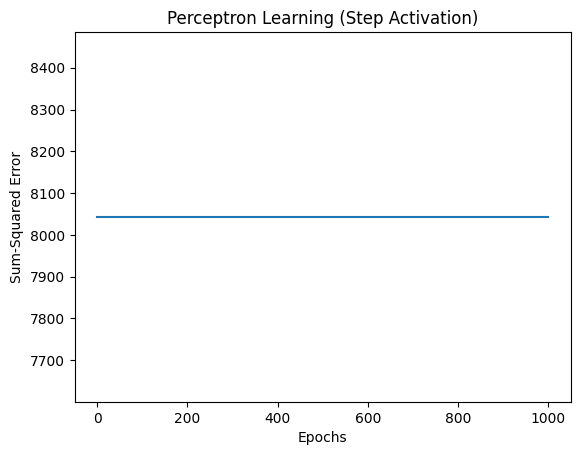

Final Weights: [ 4.13039555e+04  9.68769984e+03  9.01422259e+03  1.20155804e+04
  3.06309990e+04  2.31615420e+03  1.41155925e+04 -2.65182147e+03
 -3.53279251e+03 -1.93498458e+03  2.96879765e+03  2.31033406e+04
 -7.51957247e+03  5.18234743e+04 -6.92163573e+04 -2.05084462e+04
  5.93767142e+04  3.83844323e+03  1.66572158e+03 -1.19189099e+04
 -2.49631123e+04 -2.53173167e+04 -1.20706438e+03 -6.63569090e+02
 -1.55430441e+04 -7.47955729e+04  3.67305930e+04  4.56474520e+04
 -1.41712009e+04  7.67909113e+04 -4.00750836e+03  1.91120850e+04
  1.69881358e+04  1.49505258e+03 -2.14408630e+04 -5.35524402e+03
  6.77892063e+03  4.95096828e+04 -8.36180083e+03  3.22805499e+04
  2.56334651e+04  1.36661195e+04  2.82706303e+04 -1.06444148e+04
  5.54855509e+04 -1.38472008e+04 -3.01181978e+03  4.67715437e+04
 -5.86718472e+04  2.60902347e+04  3.77842216e+04 -3.79792607e+04
 -1.68353747e+03  3.33756261e+04 -2.02539548e+04 -1.69429579e+04
  6.07402094e+03 -8.88127784e+02 -1.18927735e+04  6.85593005e+04
 -2.749839

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Load your dataset ---
df = pd.read_excel("BERT_Embeddings.xlsx")

# --- Prepare features and target ---
X = df.drop(columns=['label','Student','Teacher']).values
y = df['label'].values

# --- Step activation function (from A1) ---
def step_activation(x):
    return 1 if x >= 0 else 0

# --- Summation unit (from A1) ---
def summation(inputs, weights, bias):
    return np.dot(inputs, weights) + bias

# --- Comparator unit (from A1) ---
def comparator_error(y_true, y_pred):
    return (y_true - y_pred) ** 2

# --- A2: Perceptron Training with Step Activation ---
def train_perceptron_step(X, y, lr=0.05, max_epochs=1000, tol=0.002):
    # Initial weights and bias as given in assignment
    weights = np.array([0.2, -0.75] + [0]*(X.shape[1]-2))  # extend if dataset has more features
    bias = 10
    errors = []

    for epoch in range(max_epochs):
        total_error = 0
        for xi, target in zip(X, y):
            summ = summation(xi, weights, bias)
            output = step_activation(summ)
            error = target - output
            weights += lr * error * xi
            bias += lr * error
            total_error += error**2
        errors.append(total_error)
        if total_error <= tol:
            break

    # Plot error vs epochs
    plt.plot(errors)
    plt.xlabel("Epochs")
    plt.ylabel("Sum-Squared Error")
    plt.title("Perceptron Learning (Step Activation)")
    plt.show()

    return weights, bias, len(errors)

# --- Run training on your dataset ---
weights, bias, epochs = train_perceptron_step(X, y)
print("Final Weights:", weights)
print("Final Bias:", bias)
print("Epochs until convergence:", epochs)


**A3**

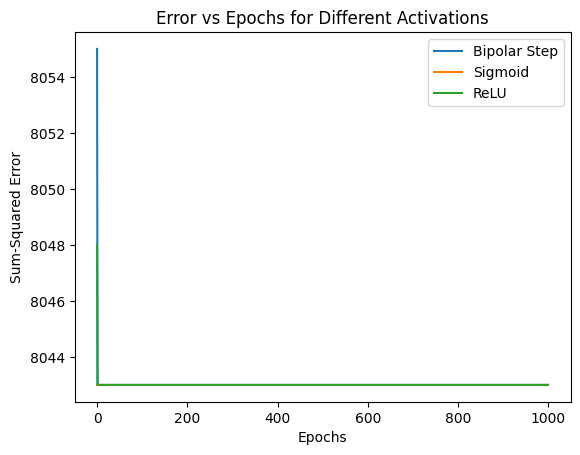

Iterations to converge: {'Bipolar Step': 1000, 'Sigmoid': 1000, 'ReLU': 1000}


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Load your dataset ---
df = pd.read_excel("BERT_Embeddings.xlsx")

# --- Prepare features and target ---
X = df.drop(columns=['label','Student','Teacher']).values
y = df['label'].values

# --- Activation functions ---
def bipolar_step_activation(x):
    if x > 0: return 1
    elif x == 0: return 0
    else: return -1

def sigmoid_activation(x):
    return 1 / (1 + np.exp(-x))

def relu_activation(x):
    return np.maximum(0, x)

# --- Summation unit ---
def summation(inputs, weights, bias):
    return np.dot(inputs, weights) + bias

# --- Training function with chosen activation ---
def train_with_activation(X, y, activation_fn, lr=0.05, max_epochs=1000, tol=0.002):
    n_features = X.shape[1]
    weights = np.random.uniform(-0.5, 0.5, n_features)
    bias = np.random.uniform(-0.5, 0.5)
    errors = []

    for epoch in range(max_epochs):
        total_error = 0
        for xi, target in zip(X, y):
            summ = summation(xi, weights, bias)
            output = activation_fn(summ)

            # Threshold for continuous activations
            if activation_fn in [sigmoid_activation, relu_activation]:
                output = 1 if output >= 0.5 else 0

            error = target - output
            weights += lr * error * xi
            bias += lr * error
            total_error += error**2
        errors.append(total_error)
        if total_error <= tol:
            break
    return len(errors), errors

# --- Compare activations ---
def compare_activations(X, y):
    activations = {
        "Bipolar Step": bipolar_step_activation,
        "Sigmoid": sigmoid_activation,
        "ReLU": relu_activation
    }
    results = {}
    for name, fn in activations.items():
        epochs, errs = train_with_activation(X, y, fn)
        results[name] = epochs
        plt.plot(errs, label=name)
    plt.xlabel("Epochs")
    plt.ylabel("Sum-Squared Error")
    plt.legend()
    plt.title("Error vs Epochs for Different Activations")
    plt.show()
    return results

# --- Run comparison on your dataset ---
results = compare_activations(X, y)
print("Iterations to converge:", results)


**A4**

Learning rate 0.1 -> Epochs until convergence: 1000
Learning rate 0.2 -> Epochs until convergence: 1000
Learning rate 0.3 -> Epochs until convergence: 1000
Learning rate 0.4 -> Epochs until convergence: 1000
Learning rate 0.5 -> Epochs until convergence: 1000
Learning rate 0.6 -> Epochs until convergence: 1000
Learning rate 0.7 -> Epochs until convergence: 1000
Learning rate 0.8 -> Epochs until convergence: 1000
Learning rate 0.9 -> Epochs until convergence: 1000
Learning rate 1.0 -> Epochs until convergence: 1000


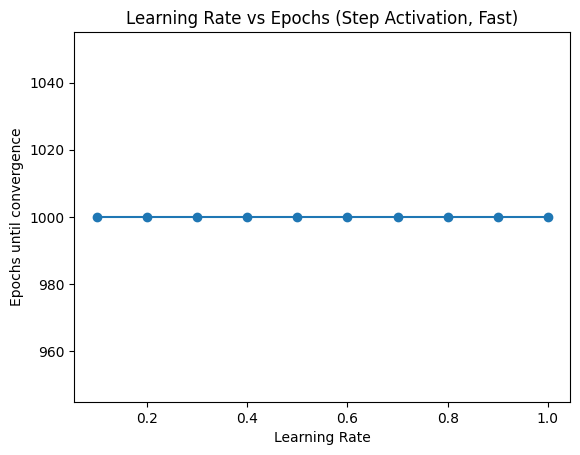

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Load dataset ---
df = pd.read_excel("BERT_Embeddings.xlsx")
X = df.drop(columns=['label','Student','Teacher']).values
y = df['label'].values

# --- Step activation ---
def step_activation(x):
    return (x >= 0).astype(int)

# --- Training function (vectorized) ---
def train_perceptron_step_fast(X, y, lr, max_epochs=1000, tol=0.002):
    n_samples, n_features = X.shape
    weights = np.array([0.2, -0.75] + [0]*(n_features-2))
    bias = 10
    errors = []

    for epoch in range(max_epochs):
        # Compute all outputs at once
        summ = np.dot(X, weights) + bias
        outputs = step_activation(summ)

        # Errors
        error = y - outputs
        total_error = np.sum(error**2)
        errors.append(total_error)

        # Update weights and bias in one step
        weights += lr * np.dot(error, X) / n_samples
        bias += lr * np.mean(error)

        if total_error <= tol:
            break
    return len(errors)

# --- A4: Vary learning rates ---
learning_rates = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0]
epochs_list = []

for lr in learning_rates:
    epochs = train_perceptron_step_fast(X, y, lr)
    epochs_list.append(epochs)
    print(f"Learning rate {lr} -> Epochs until convergence: {epochs}")

# --- Plot ---
plt.plot(learning_rates, epochs_list, marker='o')
plt.xlabel("Learning Rate")
plt.ylabel("Epochs until convergence")
plt.title("Learning Rate vs Epochs (Step Activation, Fast)")
plt.show()


**A5**

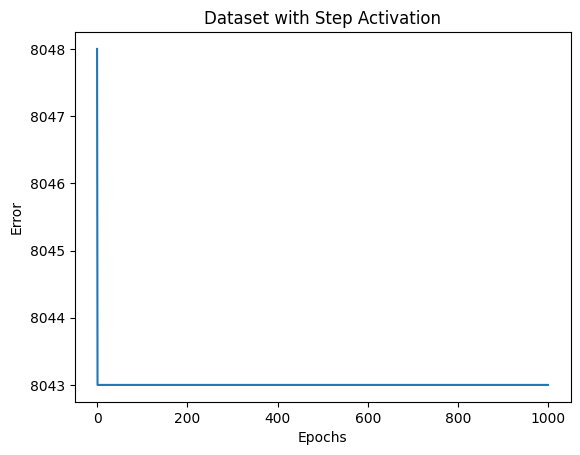

Step activation epochs: 1000


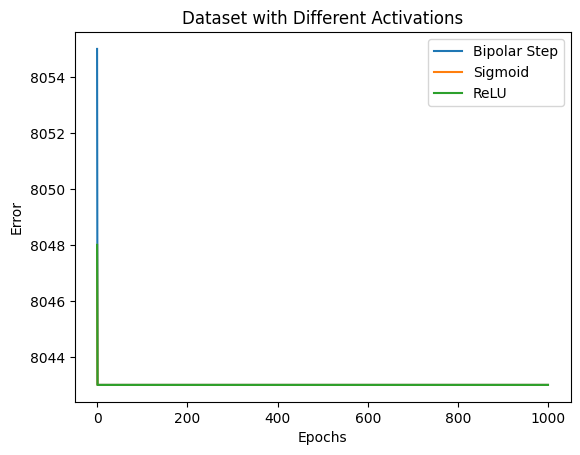

Iterations to converge: {'Bipolar Step': 1000, 'Sigmoid': 1000, 'ReLU': 1000}


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Load your dataset ---
df = pd.read_excel("BERT_Embeddings.xlsx")

# --- Prepare features and target ---
X = df.drop(columns=['label','Student','Teacher']).values
y = df['label'].values

# --- A1 Functions ---
def summation(inputs, weights, bias):
    return np.dot(inputs, weights) + bias

def step_activation(x):
    return 1 if x >= 0 else 0

def bipolar_step_activation(x):
    if x > 0: return 1
    elif x == 0: return 0
    else: return -1

def sigmoid_activation(x):
    return 1 / (1 + np.exp(-x))

def relu_activation(x):
    return np.maximum(0, x)

def comparator_error(y_true, y_pred):
    return (y_true - y_pred) ** 2

# --- Training function ---
def train_perceptron(X, y, activation_fn, lr=0.1, max_epochs=1000, tol=0.002):
    weights = np.random.uniform(-0.5,0.5,X.shape[1])
    bias = np.random.uniform(-0.5,0.5)
    errors = []

    for epoch in range(max_epochs):
        total_error = 0
        for xi, target in zip(X,y):
            summ = summation(xi, weights, bias)
            output = activation_fn(summ)

            # Threshold for continuous activations
            if activation_fn in [sigmoid_activation, relu_activation]:
                output = 1 if output >= 0.5 else 0

            error = target - output
            weights += lr * error * xi
            bias += lr * error
            total_error += error**2
        errors.append(total_error)
        if total_error <= tol:
            break
    return len(errors), errors

# --- A2: Step activation ---
epochs_step, errs_step = train_perceptron(X,y,step_activation)
plt.plot(errs_step)
plt.title("Dataset with Step Activation")
plt.xlabel("Epochs")
plt.ylabel("Error")
plt.show()
print("Step activation epochs:", epochs_step)

# --- A3: Compare Bipolar Step, Sigmoid, ReLU ---
activations = {
    "Bipolar Step": bipolar_step_activation,
    "Sigmoid": sigmoid_activation,
    "ReLU": relu_activation
}
results = {}
for name, fn in activations.items():
    epochs, errs = train_perceptron(X,y,fn)
    results[name] = epochs
    plt.plot(errs, label=name)

plt.title("Dataset with Different Activations")
plt.xlabel("Epochs")
plt.ylabel("Error")
plt.legend()
plt.show()

print("Iterations to converge:", results)


**A6**


Final Weights: [ 2.52934685e+01  5.41257246e+00  5.08402104e+00  7.49614939e+00
  1.87578207e+01  1.46621076e+00  8.30723500e+00 -1.26838965e+00
 -2.62575676e+00 -1.47566487e+00  1.31588388e+00  1.38627748e+01
 -4.67320496e+00  3.09729201e+01 -4.13372964e+01 -1.28391530e+01
  3.63113643e+01  1.84533762e+00  7.42294230e-01 -6.85719108e+00
 -1.49120618e+01 -1.57523263e+01 -2.32272153e-01 -6.03244469e-01
 -9.22021859e+00 -4.52001953e+01  2.20430988e+01  2.80147006e+01
 -8.84206447e+00  4.66095016e+01 -2.24448909e+00  1.10571484e+01
  9.97224510e+00  1.31447770e+00 -1.29595541e+01 -3.09262061e+00
  4.46690285e+00  2.97635084e+01 -5.16007902e+00  1.95210112e+01
  1.55126307e+01  8.06345902e+00  1.72464179e+01 -6.63381351e+00
  3.30467409e+01 -8.07478488e+00 -2.26538341e+00  2.81470364e+01
 -3.53246760e+01  1.54372958e+01  2.24198508e+01 -2.31219197e+01
 -8.92994235e-01  1.99988965e+01 -1.22442723e+01 -1.06492896e+01
  4.09949016e+00 -7.70904722e-01 -6.74947763e+00  4.14322604e+01
 -1.633847

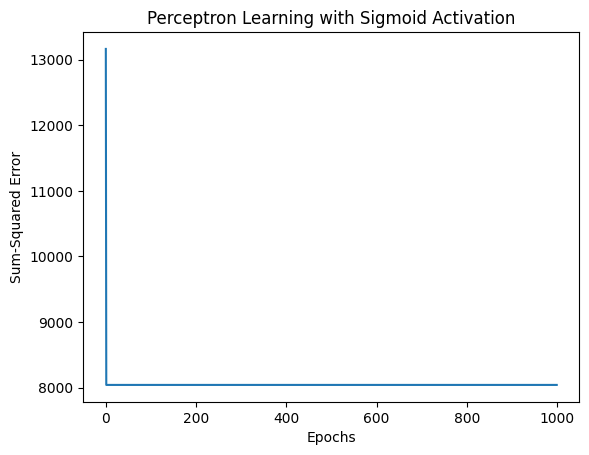

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Load your dataset ---
df = pd.read_excel("BERT_Embeddings.xlsx")

# --- Prepare features and target ---
X = df.drop(columns=['label','Student','Teacher']).values
y = df['label'].values

# --- Sigmoid activation ---
def sigmoid_activation(x):
    return 1 / (1 + np.exp(-x))

# --- Summation unit ---
def summation(inputs, weights, bias):
    return np.dot(inputs, weights) + bias

# --- Training function with Sigmoid ---
def train_perceptron_sigmoid(X, y, lr=0.1, max_epochs=1000, tol=0.002):
    n_features = X.shape[1]
    weights = np.random.uniform(-0.5, 0.5, n_features)
    bias = np.random.uniform(-0.5, 0.5)
    errors = []

    for epoch in range(max_epochs):
        # Forward pass
        summ = np.dot(X, weights) + bias
        outputs = sigmoid_activation(summ)

        # Threshold outputs to 0/1 for classification
        preds = (outputs >= 0.5).astype(int)

        # Error
        error = y - preds
        total_error = np.sum(error**2)
        errors.append(total_error)

        # Weight update (perceptron rule with sigmoid outputs)
        weights += lr * np.dot(error, X) / len(X)
        bias += lr * np.mean(error)

        if total_error <= tol:
            break

    return weights, bias, len(errors), errors

# --- Run training ---
weights, bias, epochs, errors = train_perceptron_sigmoid(X, y, lr=0.1)

print("Final Weights:", weights)
print("Final Bias:", bias)
print("Epochs until convergence:", epochs)

# --- Plot error vs epochs ---
plt.plot(errors)
plt.xlabel("Epochs")
plt.ylabel("Sum-Squared Error")
plt.title("Perceptron Learning with Sigmoid Activation")
plt.show()


**A7**

Perceptron (Sigmoid) Weights: [ 2.47130808e+01  5.35691487e+00  5.48016982e+00  7.43419974e+00
  1.84819051e+01  9.24278831e-01  8.11448162e+00 -2.01627773e+00
 -1.83112488e+00 -1.62797084e+00  1.87485072e+00  1.43752546e+01
 -4.89347290e+00  3.16250225e+01 -4.22556209e+01 -1.26654701e+01
  3.54379511e+01  2.60776032e+00  1.02305410e+00 -7.45508667e+00
 -1.50435508e+01 -1.57102599e+01 -7.98782320e-01 -7.96693960e-01
 -9.85788519e+00 -4.48636639e+01  2.19794638e+01  2.78222820e+01
 -8.75415963e+00  4.61274023e+01 -2.18006358e+00  1.19218200e+01
  9.96155383e+00  1.12839109e+00 -1.30867975e+01 -3.63581528e+00
  4.20799246e+00  3.02518803e+01 -5.25210897e+00  1.94545231e+01
  1.52028221e+01  7.83346470e+00  1.75208472e+01 -6.22789299e+00
  3.40012658e+01 -8.43472115e+00 -1.43892951e+00  2.81299282e+01
 -3.54323246e+01  1.53965562e+01  2.31940483e+01 -2.29887327e+01
 -1.15628099e+00  1.99868588e+01 -1.26970861e+01 -1.06391026e+01
  3.82471581e+00 -7.80771867e-01 -7.30542444e+00  4.14317378

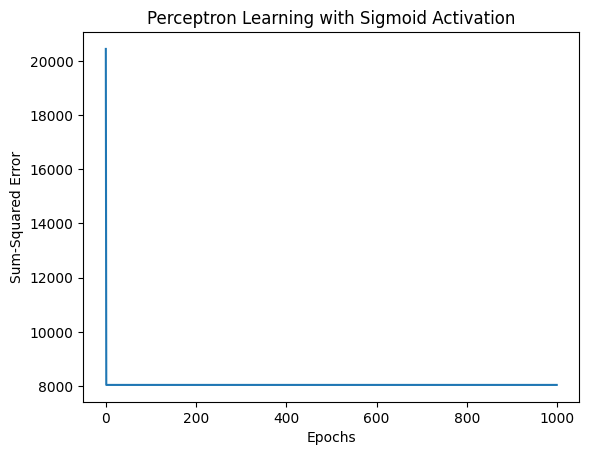

Pseudo-inverse Weights (including bias): [ -4564.2327067   -4476.63014097  -4495.67734499  -4612.15280675
  -4488.54061281  -4478.65005594  -4391.42914867  -4545.34528331
  -4271.97008517  -4722.76439599  -4465.80834347  -4465.70461685
  -4146.19740785  -4588.70039589  -4641.02943075  -4445.5699685
  -4582.95115117  -4374.61325705  -4500.91598464  -4463.47826845
  -4511.46210112  -4532.41256449  -4602.75774098  -4448.17233719
  -4486.1533138   -4498.85433912  -4299.95495455  -4423.99338506
  -4226.49896517  -3952.18322177  -4452.95047084  -4438.79022775
  -4406.07827207  -4574.084412    -4465.38266799  -4427.35293493
  -4520.10608781  -4373.03961283  -4572.29245487  -4521.64378278
  -4540.27329573  -4608.1323377   -4243.08231781  -4459.30108015
  -4317.17215918  -4231.86111348  -4587.04853252  -4192.7179559
  -4440.20939004  -4434.2013609   -4294.88592231  -4495.11122107
  -4463.47416427  -4336.02141202  -4523.3872037   -4429.09358777
  -4301.68359663  -4462.80192013  -4661.18144604  -

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Load your dataset ---
df = pd.read_excel("BERT_Embeddings.xlsx")

# --- Prepare features and target ---
X = df.drop(columns=['label','Student','Teacher']).values
y = df['label'].values

# --- Sigmoid activation ---
def sigmoid_activation(x):
    return 1 / (1 + np.exp(-x))

# --- Perceptron training (from A6) ---
def train_perceptron_sigmoid(X, y, lr=0.1, max_epochs=1000, tol=0.002):
    n_features = X.shape[1]
    weights = np.random.uniform(-0.5, 0.5, n_features)
    bias = np.random.uniform(-0.5, 0.5)
    errors = []

    for epoch in range(max_epochs):
        summ = np.dot(X, weights) + bias
        outputs = sigmoid_activation(summ)
        preds = (outputs >= 0.5).astype(int)

        error = y - preds
        total_error = np.sum(error**2)
        errors.append(total_error)

        weights += lr * np.dot(error, X) / len(X)
        bias += lr * np.mean(error)

        if total_error <= tol:
            break

    return weights, bias, len(errors), errors

# --- Train perceptron ---
weights_p, bias_p, epochs, errors = train_perceptron_sigmoid(X, y)
print("Perceptron (Sigmoid) Weights:", weights_p)
print("Bias:", bias_p)
print("Epochs until convergence:", epochs)

plt.plot(errors)
plt.xlabel("Epochs")
plt.ylabel("Sum-Squared Error")
plt.title("Perceptron Learning with Sigmoid Activation")
plt.show()

# --- Matrix Pseudo-Inverse solution ---
# Add bias term to X
X_bias = np.hstack([X, np.ones((X.shape[0],1))])
# Compute pseudo-inverse
W_pinv = np.linalg.pinv(X_bias).dot(y)

print("Pseudo-inverse Weights (including bias):", W_pinv)

# --- Compare predictions ---
summ_pinv = np.dot(X_bias, W_pinv)
outputs_pinv = sigmoid_activation(summ_pinv)
preds_pinv = (outputs_pinv >= 0.5).astype(int)

accuracy_pinv = np.mean(preds_pinv == y)
print("Pseudo-inverse Accuracy:", accuracy_pinv)

# Perceptron accuracy
summ_p = np.dot(X, weights_p) + bias_p
outputs_p = sigmoid_activation(summ_p)
preds_p = (outputs_p >= 0.5).astype(int)
accuracy_p = np.mean(preds_p == y)
print("Perceptron Accuracy:", accuracy_p)


**A8**

Hidden Weights: [[ 0.02289126 -0.51412418]
 [ 0.3041564  -0.06857987]
 [ 0.48736519 -0.33950228]
 ...
 [-0.08686137 -0.42966875]
 [ 0.14396446 -0.45312527]
 [-0.24812835 -0.3362392 ]]
Output Weights: [[77.4010296 ]
 [71.97214781]]
Epochs until convergence: 1000


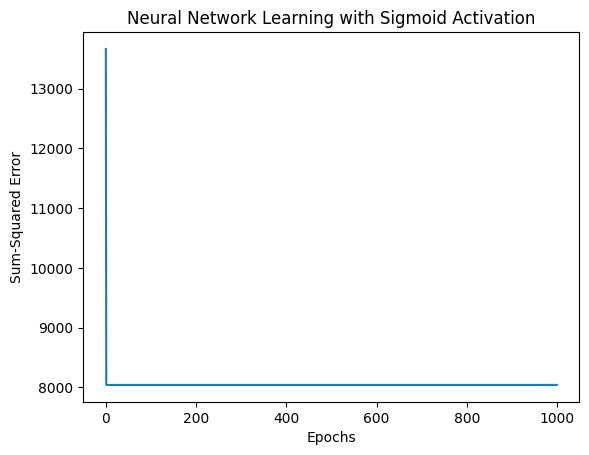

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Load your dataset ---
df = pd.read_excel("BERT_Embeddings.xlsx")

# --- Prepare features and target ---
X = df.drop(columns=['label','Student','Teacher']).values
y = df['label'].values.reshape(-1,1)   # make y column vector

# --- Sigmoid activation and derivative ---
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

# --- Backpropagation Neural Network ---
def train_nn(X, y, hidden_size=2, lr=0.05, max_epochs=1000, tol=0.002):
    n_samples, n_features = X.shape
    n_outputs = 1

    # Initialize weights
    W_hidden = np.random.uniform(-0.5, 0.5, (n_features, hidden_size))
    b_hidden = np.random.uniform(-0.5, 0.5, (1, hidden_size))
    W_output = np.random.uniform(-0.5, 0.5, (hidden_size, n_outputs))
    b_output = np.random.uniform(-0.5, 0.5, (1, n_outputs))

    errors = []

    for epoch in range(max_epochs):
        # Forward pass
        hidden_input = np.dot(X, W_hidden) + b_hidden
        hidden_output = sigmoid(hidden_input)

        final_input = np.dot(hidden_output, W_output) + b_output
        final_output = sigmoid(final_input)

        # Error
        error = y - final_output
        total_error = np.sum(error**2)
        errors.append(total_error)

        # Backpropagation
        d_output = error * sigmoid_derivative(final_output)
        d_hidden = np.dot(d_output, W_output.T) * sigmoid_derivative(hidden_output)

        # Update weights
        W_output += lr * np.dot(hidden_output.T, d_output)
        b_output += lr * np.sum(d_output, axis=0, keepdims=True)

        W_hidden += lr * np.dot(X.T, d_hidden)
        b_hidden += lr * np.sum(d_hidden, axis=0, keepdims=True)

        if total_error <= tol:
            break

    return W_hidden, W_output, b_hidden, b_output, len(errors), errors

# --- Train the network ---
W_hidden, W_output, b_hidden, b_output, epochs, errors = train_nn(X, y)

print("Hidden Weights:", W_hidden)
print("Output Weights:", W_output)
print("Epochs until convergence:", epochs)

# --- Plot error vs epochs ---
plt.plot(errors)
plt.xlabel("Epochs")
plt.ylabel("Sum-Squared Error")
plt.title("Neural Network Learning with Sigmoid Activation")
plt.show()


**A9**

Hidden Weights:
 [[ 1.46159706 -0.04705841 -0.57712883 -0.4417722 ]
 [ 0.16318956  0.44127624 -0.37065368 -0.46427445]
 [ 0.26444462  0.09267147 -0.41132311 -0.10301921]
 ...
 [ 1.31761695  0.2225995  -0.48679214  0.10922573]
 [ 0.54164453  0.11908198  0.29920314  0.1774724 ]
 [ 0.97060064 -0.28800439  0.39391641 -0.43080709]]
Output Weights:
 [[47.07966595]
 [16.03637796]
 [ 2.2203084 ]
 [77.44113447]]
Epochs until convergence: 1000


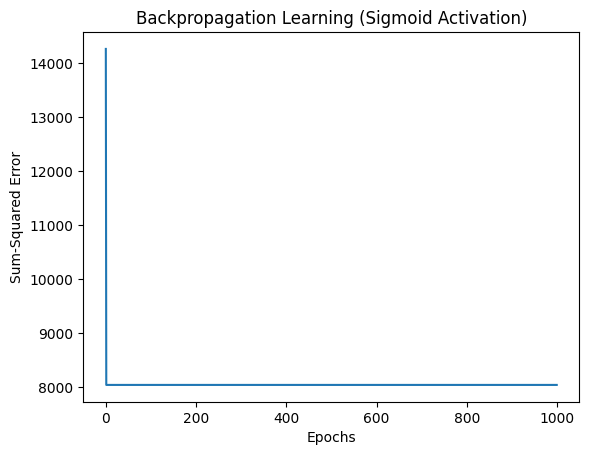

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Load your dataset ---
df = pd.read_excel("BERT_Embeddings.xlsx")

# --- Prepare features and target ---
X = df.drop(columns=['label','Student','Teacher']).values
y = df['label'].values.reshape(-1,1)   # column vector

# --- Sigmoid activation and derivative ---
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

# --- Backpropagation Neural Network ---
def train_backprop(X, y, hidden_size=4, lr=0.05, max_epochs=1000, tol=0.002):
    n_samples, n_features = X.shape
    n_outputs = 1

    # Initialize weights and biases
    W_hidden = np.random.uniform(-0.5, 0.5, (n_features, hidden_size))
    b_hidden = np.random.uniform(-0.5, 0.5, (1, hidden_size))
    W_output = np.random.uniform(-0.5, 0.5, (hidden_size, n_outputs))
    b_output = np.random.uniform(-0.5, 0.5, (1, n_outputs))

    errors = []

    for epoch in range(max_epochs):
        # Forward pass
        hidden_input = np.dot(X, W_hidden) + b_hidden
        hidden_output = sigmoid(hidden_input)

        final_input = np.dot(hidden_output, W_output) + b_output
        final_output = sigmoid(final_input)

        # Error
        error = y - final_output
        total_error = np.sum(error**2)
        errors.append(total_error)

        # Backpropagation
        d_output = error * sigmoid_derivative(final_output)
        d_hidden = np.dot(d_output, W_output.T) * sigmoid_derivative(hidden_output)

        # Update weights and biases
        W_output += lr * np.dot(hidden_output.T, d_output)
        b_output += lr * np.sum(d_output, axis=0, keepdims=True)

        W_hidden += lr * np.dot(X.T, d_hidden)
        b_hidden += lr * np.sum(d_hidden, axis=0, keepdims=True)

        if total_error <= tol:
            break

    return W_hidden, W_output, b_hidden, b_output, len(errors), errors

# --- Train the network ---
W_hidden, W_output, b_hidden, b_output, epochs, errors = train_backprop(X, y)

print("Hidden Weights:\n", W_hidden)
print("Output Weights:\n", W_output)
print("Epochs until convergence:", epochs)

# --- Plot error vs epochs ---
plt.plot(errors)
plt.xlabel("Epochs")
plt.ylabel("Sum-Squared Error")
plt.title("Backpropagation Learning (Sigmoid Activation)")
plt.show()


**A10**

Hidden Weights:
 [[-0.61686723  0.02836488 -0.51487529 -0.17580409]
 [-0.2088643  -0.40548795 -0.2976114   0.33806355]
 [-0.38092215  0.13930306  0.48803304 -0.21587024]
 ...
 [-0.35051252 -0.16801483 -0.15338598 -0.15326558]
 [ 0.39917801  0.36789946 -0.29337643  0.13014265]
 [ 0.03955159 -0.13361588 -0.45954313 -0.32445474]]
Output Weights:
 [[ -8.00665396  13.0250041 ]
 [ -6.90877826  11.52589297]
 [-14.51528258  22.81928375]
 [-13.75745551  22.17450142]]
Epochs until convergence: 2


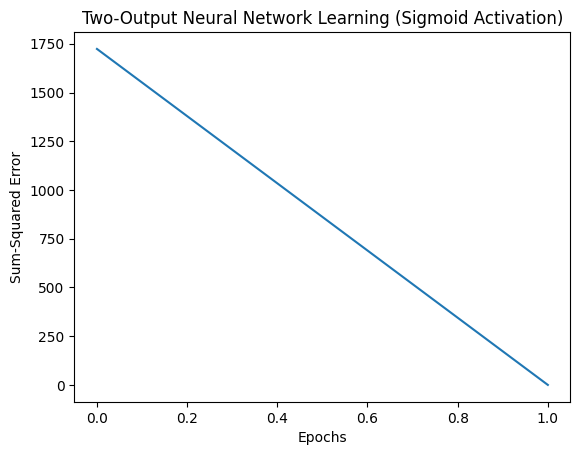

Classification Accuracy: 1.0


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Load dataset ---
df = pd.read_excel("BERT_Embeddings.xlsx")

# --- Prepare features and target ---
X = df.drop(columns=['label','Student','Teacher']).values
y = df['label'].values

# Map labels to two‑node outputs: 0 -> [1,0], 1 -> [0,1]
y_two = np.array([[1,0] if val==0 else [0,1] for val in y])

# --- Sigmoid activation and derivative ---
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

# --- Backpropagation Neural Network with 2 outputs ---
def train_nn_two_outputs(X, y, hidden_size=4, lr=0.05, max_epochs=1000, tol=0.002):
    n_samples, n_features = X.shape
    n_outputs = y.shape[1]

    # Initialize weights
    W_hidden = np.random.uniform(-0.5, 0.5, (n_features, hidden_size))
    b_hidden = np.random.uniform(-0.5, 0.5, (1, hidden_size))
    W_output = np.random.uniform(-0.5, 0.5, (hidden_size, n_outputs))
    b_output = np.random.uniform(-0.5, 0.5, (1, n_outputs))

    errors = []

    for epoch in range(max_epochs):
        # Forward pass
        hidden_input = np.dot(X, W_hidden) + b_hidden
        hidden_output = sigmoid(hidden_input)

        final_input = np.dot(hidden_output, W_output) + b_output
        final_output = sigmoid(final_input)

        # Error
        error = y - final_output
        total_error = np.sum(error**2)
        errors.append(total_error)

        # Backpropagation
        d_output = error * sigmoid_derivative(final_output)
        d_hidden = np.dot(d_output, W_output.T) * sigmoid_derivative(hidden_output)

        # Update weights
        W_output += lr * np.dot(hidden_output.T, d_output)
        b_output += lr * np.sum(d_output, axis=0, keepdims=True)

        W_hidden += lr * np.dot(X.T, d_hidden)
        b_hidden += lr * np.sum(d_hidden, axis=0, keepdims=True)

        if total_error <= tol:
            break

    return W_hidden, W_output, b_hidden, b_output, len(errors), errors, final_output

# --- Train the network ---
W_hidden, W_output, b_hidden, b_output, epochs, errors, outputs = train_nn_two_outputs(X, y_two)

print("Hidden Weights:\n", W_hidden)
print("Output Weights:\n", W_output)
print("Epochs until convergence:", epochs)

# --- Plot error vs epochs ---
plt.plot(errors)
plt.xlabel("Epochs")
plt.ylabel("Sum-Squared Error")
plt.title("Two-Output Neural Network Learning (Sigmoid Activation)")
plt.show()

# --- Evaluate predictions ---
preds = np.argmax(outputs, axis=1)   # pick the larger of O1/O2
true = np.argmax(y_two, axis=1)
accuracy = np.mean(preds == true)
print("Classification Accuracy:", accuracy)


**A11**

MLPClassifier Accuracy: 0.6759287224403503
Confusion Matrix:
 [[ 119  132  201]
 [  18  647  466]
 [  16  240 1472]]
Classification Report:
               precision    recall  f1-score   support

           1       0.78      0.26      0.39       452
           2       0.63      0.57      0.60      1131
           3       0.69      0.85      0.76      1728

    accuracy                           0.68      3311
   macro avg       0.70      0.56      0.59      3311
weighted avg       0.68      0.68      0.66      3311



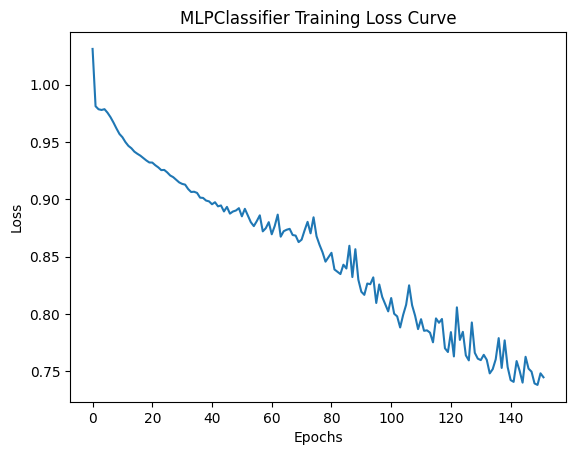

In [ ]:
import pandas as pd
import numpy as np
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt

# --- Load dataset ---
df = pd.read_excel("BERT_Embeddings.xlsx")

# --- Prepare features and target ---
X = df.drop(columns=['label','Student','Teacher']).values
y = df['label'].values

# --- Define MLPClassifier ---
mlp = MLPClassifier(
    hidden_layer_sizes=(4,),   # one hidden layer with 4 neurons
    activation='logistic',     # sigmoid activation
    solver='sgd',              # stochastic gradient descent
    learning_rate_init=0.05,   # learning rate α = 0.05
    max_iter=1000,
    tol=0.002,
    random_state=42
)

# --- Train the MLP ---
mlp.fit(X, y)

# --- Predictions ---
y_pred = mlp.predict(X)

# --- Evaluation ---
acc = accuracy_score(y, y_pred)
print("MLPClassifier Accuracy:", acc)
print("Confusion Matrix:\n", confusion_matrix(y, y_pred))
print("Classification Report:\n", classification_report(y, y_pred))

# --- Plot loss curve ---
plt.plot(mlp.loss_curve_)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("MLPClassifier Training Loss Curve")
plt.show()


**A12**

MLPClassifier Accuracy: 0.9960736937481124
Confusion Matrix:
 [[ 444    0    8]
 [   1 1127    3]
 [   1    0 1727]]
Classification Report:
               precision    recall  f1-score   support

           1       1.00      0.98      0.99       452
           2       1.00      1.00      1.00      1131
           3       0.99      1.00      1.00      1728

    accuracy                           1.00      3311
   macro avg       1.00      0.99      0.99      3311
weighted avg       1.00      1.00      1.00      3311



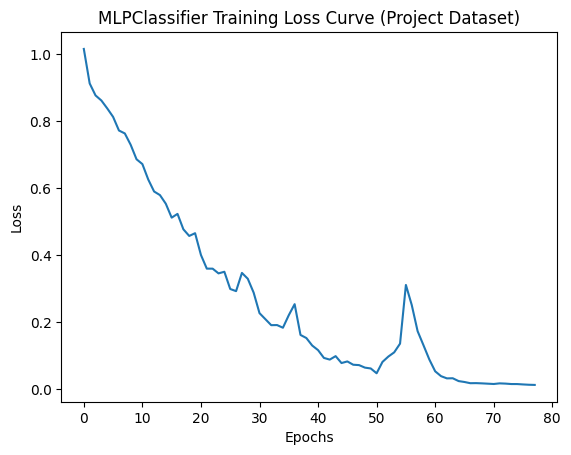

In [ ]:
import pandas as pd
import numpy as np
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt

# --- Load your dataset ---
df = pd.read_excel("BERT_Embeddings.xlsx")

# --- Prepare features and target ---
X = df.drop(columns=['label','Student','Teacher']).values
y = df['label'].values

# --- Define MLPClassifier ---
mlp = MLPClassifier(
    hidden_layer_sizes=(64,32),   # two hidden layers (64 and 32 neurons)
    activation='relu',            # ReLU activation (common for embeddings)
    solver='adam',                # Adam optimizer
    learning_rate_init=0.01,      # initial learning rate
    max_iter=1000,
    tol=0.002,
    random_state=42
)

# --- Train the MLP ---
mlp.fit(X, y)

# --- Predictions ---
y_pred = mlp.predict(X)

# --- Evaluation ---
acc = accuracy_score(y, y_pred)
print("MLPClassifier Accuracy:", acc)
print("Confusion Matrix:\n", confusion_matrix(y, y_pred))
print("Classification Report:\n", classification_report(y, y_pred))

# --- Plot loss curve ---
plt.plot(mlp.loss_curve_)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("MLPClassifier Training Loss Curve (Project Dataset)")
plt.show()
